*Aprendizaje Profundo*  
*Tarea -* Red CNN Lenet  
*Autor:* Ing. Daniel Eduardo González Alvarado  
*Profesor:* Dr. Sebastian Salazar

In [32]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

In [15]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Train: ",x_train.shape,"Test:" ,x_test.shape)

x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

Train:  (60000, 28, 28) Test: (10000, 28, 28)
(60000, 28, 28, 1) (10000, 28, 28, 1)
(60000,) (10000,)


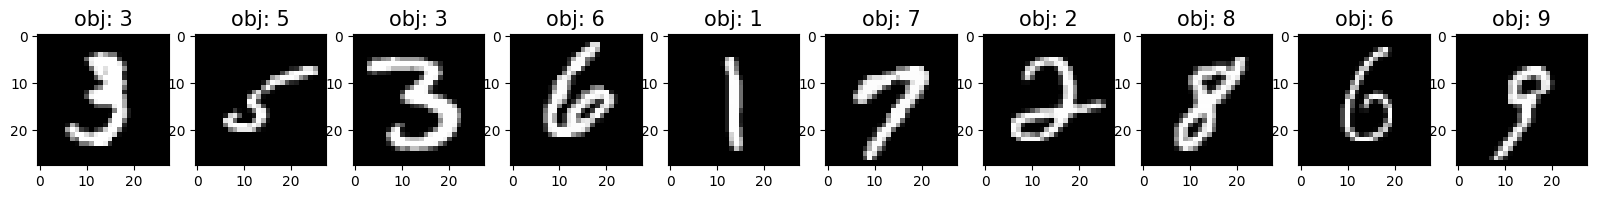

In [11]:
plt.figure(figsize=(20,4))

inicial = 10
for index, (imagen, etiqueta) in enumerate(zip(x_train[inicial:inicial+10], y_train[inicial:inicial+10])):
    plt.subplot(1, 10, index + 1)
    plt.imshow(np.reshape(imagen, (28,28)), cmap=plt.cm.gray)
    plt.title('obj: ' + str(etiqueta), fontsize=15)

![Flor](../img/lenet.jpeg)

In [25]:
model = keras.Sequential([
    layers.Conv2D(6, kernel_size=5, padding="same", activation="tanh", input_shape=(28,28,1)),
    layers.AveragePooling2D(pool_size=2, strides=2),

    layers.Conv2D(16, kernel_size=5, activation="tanh"),
    layers.AveragePooling2D(pool_size=2, strides=2),

    layers.Flatten(),
    layers.Dense(120, activation="tanh"),
    layers.Dense(84, activation="tanh"),
    layers.Dense(10, activation="softmax")
])

In [27]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)


Epoch 1/5
422/422 - 3s - 8ms/step - accuracy: 0.9363 - loss: 0.2280 - val_accuracy: 0.9802 - val_loss: 0.0689
Epoch 2/5
422/422 - 2s - 5ms/step - accuracy: 0.9779 - loss: 0.0725 - val_accuracy: 0.9855 - val_loss: 0.0516
Epoch 3/5
422/422 - 2s - 5ms/step - accuracy: 0.9837 - loss: 0.0518 - val_accuracy: 0.9872 - val_loss: 0.0456
Epoch 4/5
422/422 - 2s - 5ms/step - accuracy: 0.9871 - loss: 0.0415 - val_accuracy: 0.9883 - val_loss: 0.0448
Epoch 5/5
422/422 - 2s - 5ms/step - accuracy: 0.9887 - loss: 0.0351 - val_accuracy: 0.9895 - val_loss: 0.0411


In [29]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.9878


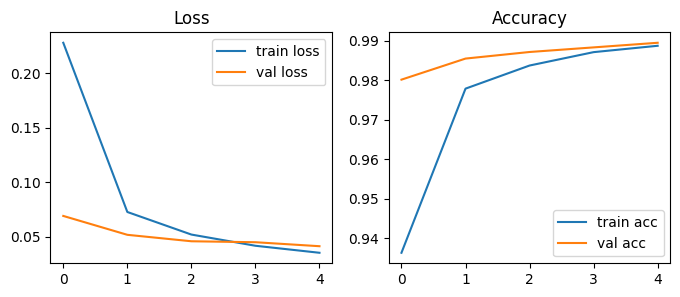

In [33]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend(); plt.title("Loss")
plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend(); plt.title("Accuracy")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


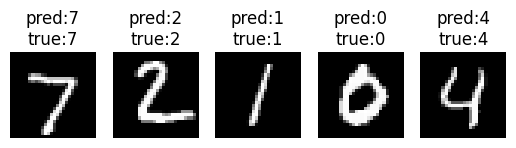

In [34]:

i = 0
preds = model.predict(x_test[i:i+5])
pred_labels = np.argmax(preds, axis=1)
for k in range(5):
    plt.subplot(1,5,k+1)
    plt.imshow(x_test[k].reshape(28,28), cmap="gray")
    plt.title(f"pred:{pred_labels[k]}\ntrue:{y_test[k]}")
    plt.axis("off")
plt.show()

In [35]:
probs = model.predict(x_test[:8], verbose=0)
preds = probs.argmax(axis=1)
print("Predicciones:", preds)
print("Etiquetas reales:", y_test[:8])

Predicciones: [7 2 1 0 4 1 4 9]
Etiquetas reales: [7 2 1 0 4 1 4 9]


In [ ]:
#model.save("lenet_mnist.h5")